In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt



In [3]:
# ---------------------------------------------------------------------
# Load results
# ---------------------------------------------------------------------
thickness_sweep_results = xr.open_dataset(
    "run_data/foswec_added_thickness_sweep_results.nc"
)

# If you saved to the non-stiffness filename instead, use:
# thickness_sweep_results = xr.open_dataset(
#     "run_data/foswec_added_thickness_sweep_results.nc"
# )


# ---------------------------------------------------------------------
# Inspect one case
# ---------------------------------------------------------------------
wf = 1 / 3
amp = 0.25

case_results = thickness_sweep_results.sel(
    wavefreq=wf,
    amplitude=amp,
    method="nearest",
)

print(case_results["avg_power"].values)
print(case_results.data_vars)


[-0.28568976 -0.29755926]
Data variables:
    avg_power                        (added_thickness) float64 16B -0.2857 -0...
    objective                        (added_thickness) float64 16B ...
    generated_power                  (added_thickness) float64 16B ...
    success                          (added_thickness) bool 2B ...
    flap_thickness_bottom            (added_thickness) float64 16B ...
    flap_thickness_top               (added_thickness) float64 16B ...
    opt_power                        (added_thickness) float64 16B ...
    elec_power_W                     (added_thickness) float64 16B ...
    mean_elec_power                  (added_thickness) float64 16B ...
    opt_stiffness_flap1              (added_thickness) float64 16B ...
    opt_stiffness_flap2              (added_thickness) float64 16B ...
    initial_stiffness_flap1_used     (added_thickness) float64 16B ...
    initial_stiffness_flap2_used     (added_thickness) float64 16B ...
    n_stiffness_attempts     

In [4]:
print(thickness_sweep_results["flap1_peak_rotation_utilization"].values)

[[[0.24294426 0.24443843]]]


In [5]:

# ---------------------------------------------------------------------
# Compute power improvement relative to baseline thickness
# ---------------------------------------------------------------------
baseline_power = thickness_sweep_results["elec_power_W"].sel(
    added_thickness=0.0
)

thickness_sweep_results["power_improvement_pct"] = (
    100.0
    * (
        thickness_sweep_results["elec_power_W"] - baseline_power
    )
    / np.abs(baseline_power)
)

# ---------------------------------------------------------------------
# Find best thickness by wave condition
# ---------------------------------------------------------------------
valid_power = thickness_sweep_results["elec_power_W"]

best_added_thickness = valid_power.idxmax(
    dim="added_thickness",
    skipna=True,
)

best_power = valid_power.max(
    dim="added_thickness",
    skipna=True,
)

thickness_sweep_results["best_added_thickness"] = best_added_thickness
thickness_sweep_results["best_generated_power"] = best_power

print("\nBest added thickness by wave condition:")

for wavefreq in thickness_sweep_results["wavefreq"].values:
    for amplitude in thickness_sweep_results["amplitude"].values:
        bt = thickness_sweep_results["best_added_thickness"].sel(
            wavefreq=wavefreq,
            amplitude=amplitude,
        ).values

        bp = thickness_sweep_results["best_generated_power"].sel(
            wavefreq=wavefreq,
            amplitude=amplitude,
        ).values

        print(
            f"wavefreq={wavefreq:.4f} Hz, "
            f"A={amplitude:.3f} m: "
            f"best_added_thickness={float(bt):g} m, "
            f"best_power={float(bp):.6g}"
        )



Best added thickness by wave condition:
wavefreq=0.1667 Hz, A=0.050 m: best_added_thickness=0.01 m, best_power=0.297559


In [6]:
# ---------------------------------------------------------------------
# Generic thickness sweep plot
# ---------------------------------------------------------------------
def plot_xr_thickness_res(ds, qnty, mask_success=True):
    """
    Plot quantity versus added_thickness.

    One subplot per wave frequency.
    One line per amplitude.
    """

    wavefreq_vals = ds["wavefreq"].values
    amplitude_vals = ds["amplitude"].values

    fig, axs = plt.subplots(
        1,
        len(wavefreq_vals),
        figsize=(2.2 * len(wavefreq_vals), 3.2),
        sharey=True,
        constrained_layout=True,
    )

    axs = np.atleast_1d(axs)

    for ax, wf in zip(axs, wavefreq_vals):
        for amp in amplitude_vals:
            y = ds[qnty].sel(
                wavefreq=wf,
                amplitude=amp,
            )

            if mask_success and "success" in ds:
                y = y.where(
                    ds["success"].sel(
                        wavefreq=wf,
                        amplitude=amp,
                    )
                )

            ax.plot(
                ds["added_thickness"],
                y,
                marker="o",
                label=f"A={amp:.3f} m",
            )

        ax.set_title(f"wf = {wf:.3f} Hz")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Added thickness [m]")

    axs[0].set_ylabel(qnty)
    axs[-1].legend(fontsize=8)

    return fig, axs

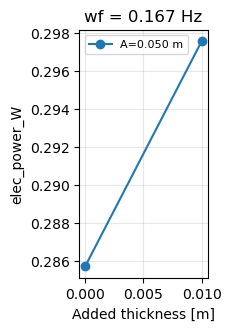

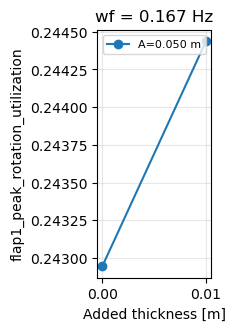

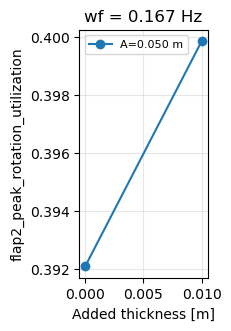

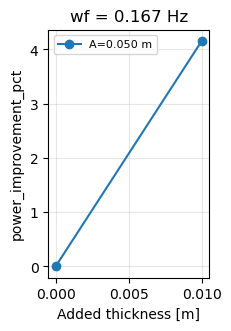

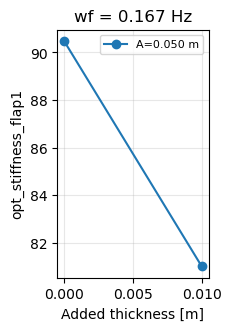

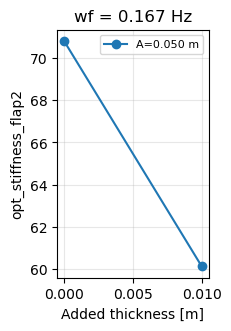

In [7]:
# ---------------------------------------------------------------------
# Plots matching mass study
# ---------------------------------------------------------------------
plot_xr_thickness_res(thickness_sweep_results, "elec_power_W", mask_success=False)
plot_xr_thickness_res(thickness_sweep_results, "flap1_peak_rotation_utilization", mask_success=False)
plot_xr_thickness_res(thickness_sweep_results, "flap2_peak_rotation_utilization", mask_success=False)
plot_xr_thickness_res(thickness_sweep_results, "power_improvement_pct", mask_success=False)

# Only plot these if stiffness optimization variables exist
if "opt_stiffness_flap1" in thickness_sweep_results:
    plot_xr_thickness_res(thickness_sweep_results, "opt_stiffness_flap1", mask_success=False)

if "opt_stiffness_flap2" in thickness_sweep_results:
    plot_xr_thickness_res(thickness_sweep_results, "opt_stiffness_flap2", mask_success=False)

if "initial_stiffness_used" in thickness_sweep_results:
    plot_xr_thickness_res(thickness_sweep_results, "initial_stiffness_used", mask_success=False)

plt.show()




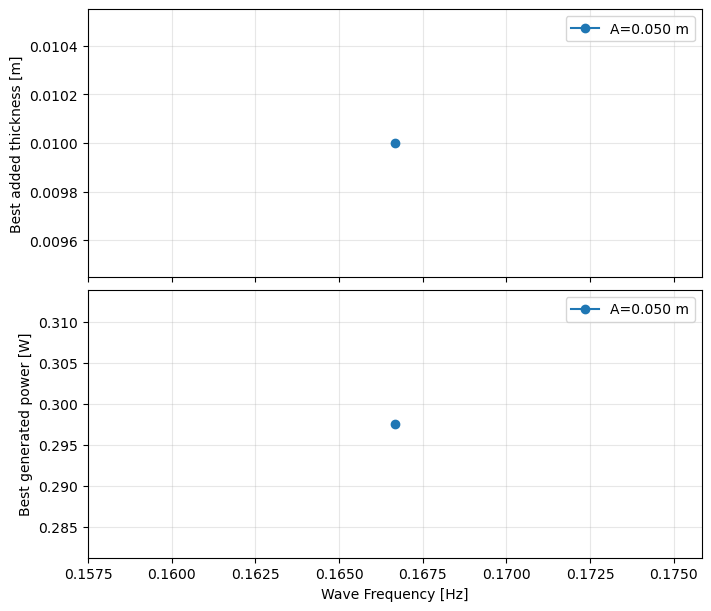

In [8]:
# ---------------------------------------------------------------------
# Best thickness plot
# ---------------------------------------------------------------------
fig, axs = plt.subplots(
    2,
    1,
    figsize=(7, 6),
    sharex=True,
    constrained_layout=True,
)

for amp in thickness_sweep_results["amplitude"].values:
    axs[0].plot(
        thickness_sweep_results["wavefreq"],
        thickness_sweep_results["best_added_thickness"].sel(amplitude=amp),
        marker="o",
        label=f"A={amp:.3f} m",
    )

    axs[1].plot(
        thickness_sweep_results["wavefreq"],
        thickness_sweep_results["best_generated_power"].sel(amplitude=amp),
        marker="o",
        label=f"A={amp:.3f} m",
    )

axs[0].set_ylabel("Best added thickness [m]")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].set_xlabel("Wave Frequency [Hz]")
axs[1].set_ylabel("Best generated power [W]")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

plt.show()

In [9]:
thickness_sweep_results.close()